IVI Media Service and Audio HAL Message Flow Simulation
Module : Module 6 - IVI In-Vehicle Infotainment Systems
Project: Option 3

IVI SYSTEM ARCHITECTURE
----------------------------------------------------------------------
User ->
IVI UI ->
Media Service ->
Audio Framework ->
Audio HAL ->
Audio Driver ->
Vehicle Speakers


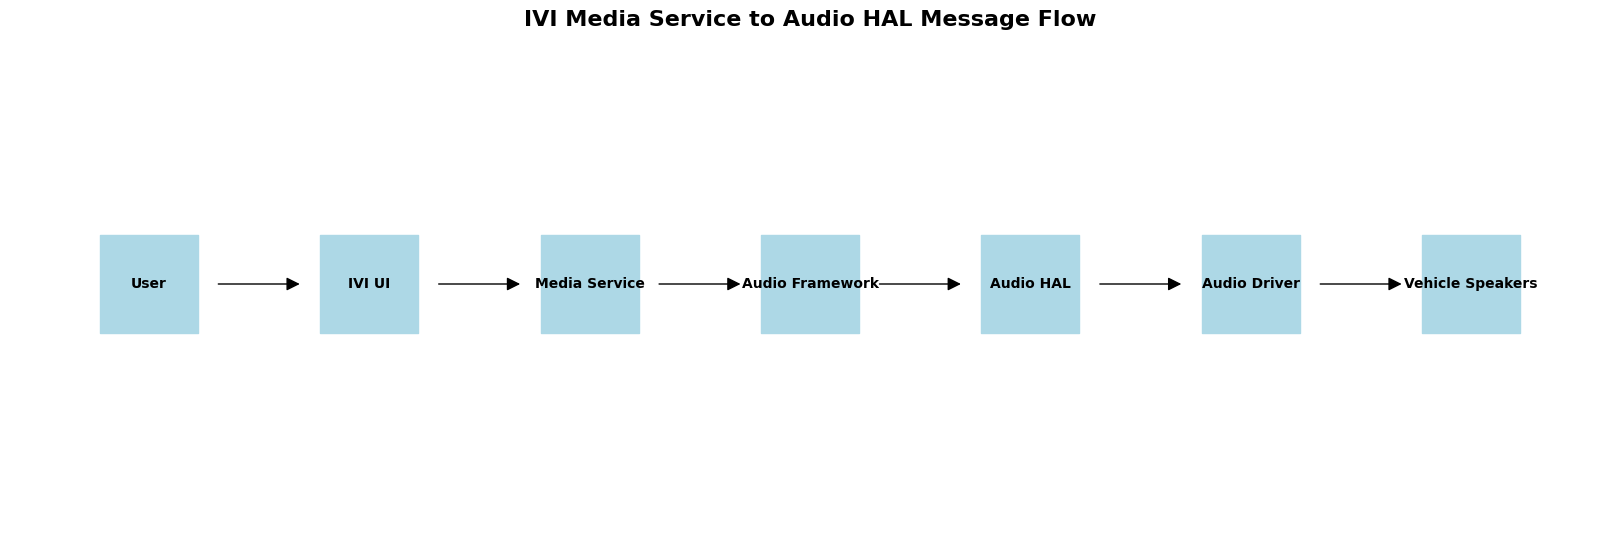


Architecture diagram saved as: IVI_Message_Flow.png

SIMULATION 1 : USER PRESSES PLAY
19:35:38.153 | IVI UI             | USER_INPUT   | User pressed PLAY button
19:35:38.153 | Media Service      | COMMAND_RX   | PLAY command received from IVI UI
19:35:38.153 | Media Service      | PROCESSING   | Preparing selected media track
19:35:38.153 | Audio Framework    | AUDIO_REQUEST | Creating audio playback request
19:35:38.153 | Audio HAL          | HAL_OPEN     | Opening audio output stream
19:35:38.153 | Audio HAL          | HAL_READY    | Audio output stream initialized
19:35:38.153 | Audio Driver       | PCM_DATA     | Receiving PCM audio data
19:35:38.153 | Vehicle Speakers   | PLAYBACK     | Audio output started

SIMULATION 2 : USER PRESSES PAUSE
19:35:38.153 | IVI UI             | USER_INPUT   | User pressed PAUSE button
19:35:38.153 | Media Service      | COMMAND_RX   | PAUSE command received
19:35:38.153 | Audio Framework    | AUDIO_REQUEST | Pause request forwarded
19:35:38.153 |

,timestamp,component,event,message
0,19:35:38.153,IVI UI,USER_INPUT,User pressed PLAY button
1,19:35:38.153,Media Service,COMMAND_RX,PLAY command received from IVI UI
2,19:35:38.153,Media Service,PROCESSING,Preparing selected media track
3,19:35:38.153,Audio Framework,AUDIO_REQUEST,Creating audio playback request
4,19:35:38.153,Audio HAL,HAL_OPEN,Opening audio output stream
5,19:35:38.153,Audio HAL,HAL_READY,Audio output stream initialized
6,19:35:38.153,Audio Driver,PCM_DATA,Receiving PCM audio data
7,19:35:38.153,Vehicle Speakers,PLAYBACK,Audio output started
8,19:35:38.153,IVI UI,USER_INPUT,User pressed PAUSE button
9,19:35:38.153,Media Service,COMMAND_RX,PAUSE command received



Log file saved to: logs/simulated_android_logs.txt

MESSAGES PROCESSED BY COMPONENT


,Message Count
component,
Media Service,6
Audio HAL,6
IVI UI,5
Audio Framework,5
Vehicle Speakers,5
Audio Driver,3


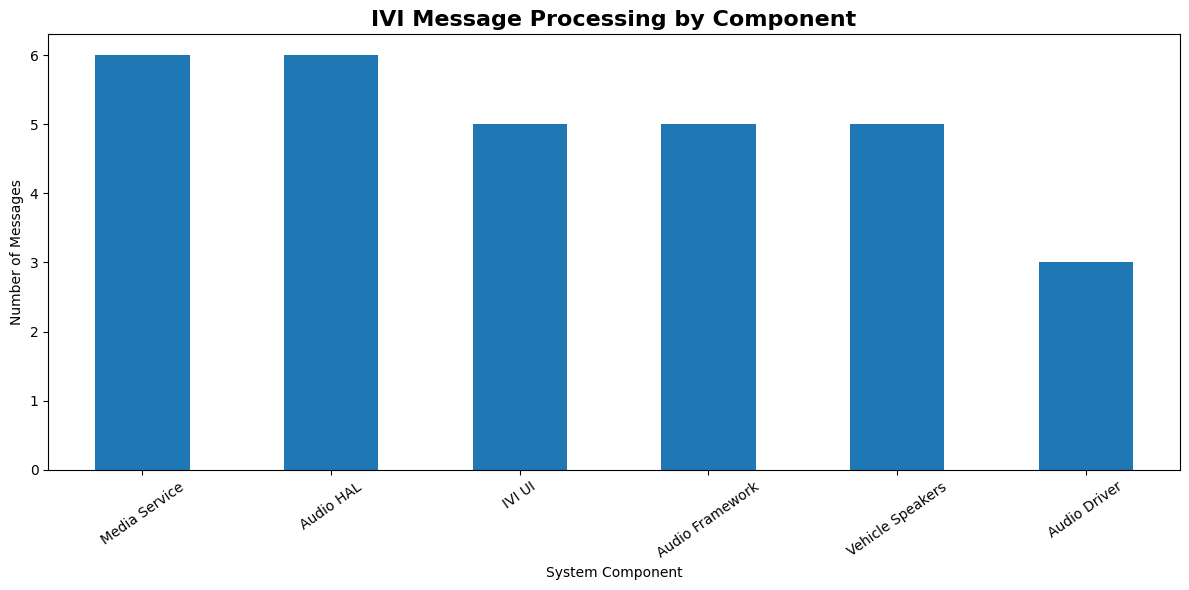

Chart saved as: IVI_Message_Statistics.png

EVENT ANALYSIS


,Occurrences
event,
USER_INPUT,5
COMMAND_RX,5
AUDIO_REQUEST,5
PLAYBACK,2
PCM_DATA,2
PROCESSING,1
HAL_READY,1
HAL_OPEN,1
HAL_PAUSE,1



COMPLETE MESSAGE FLOW

USER ACTION
     |
     v
IVI USER INTERFACE
     |
     | Command
     v
MEDIA SERVICE
     |
     | Playback Request
     v
AUDIO FRAMEWORK
     |
     | Audio Stream Request
     v
AUDIO HAL
     |
     | PCM Audio Data
     v
AUDIO DRIVER
     |
     v
VEHICLE SPEAKERS


PROJECT SUMMARY
Total messages simulated : 30
Components involved     : 6
Event types generated   : 16

Key Observation:
User commands originate at the IVI interface and are propagated
through the Media Service and Audio Framework before reaching the
Audio HAL. The Audio HAL interfaces with the lower-level audio
driver, which ultimately produces the audio output through the
vehicle speakers.

The simulation demonstrates how a user-level action can propagate
through multiple IVI software layers.


Generated project files:
1. IVI_Message_Flow.png
2. IVI_Message_Statistics.png
3. logs/simulated_android_logs.txt

PROJECT COMPLETED SUCCESSFULLY!


In [1]:
# ============================================================
# MODULE 6 - IVI (IN-VEHICLE INFOTAINMENT) SYSTEM
# Media Service <-> Audio HAL Message Flow Simulation
# ============================================================

# Install required libraries
!pip -q install matplotlib networkx pandas

import time
import random
import os
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from datetime import datetime

# ============================================================
# 1. PROJECT INFORMATION
# ============================================================

PROJECT_TITLE = "IVI Media Service and Audio HAL Message Flow Simulation"
MODULE = "Module 6 - IVI In-Vehicle Infotainment Systems"
OPTION = "Option 3"

print("=" * 70)
print(PROJECT_TITLE)
print("=" * 70)
print(f"Module : {MODULE}")
print(f"Project: {OPTION}")
print("=" * 70)

# ============================================================
# 2. IVI SYSTEM ARCHITECTURE
# ============================================================

components = [
    "User",
    "IVI UI",
    "Media Service",
    "Audio Framework",
    "Audio HAL",
    "Audio Driver",
    "Vehicle Speakers"
]

print("\nIVI SYSTEM ARCHITECTURE")
print("-" * 70)

for i, component in enumerate(components):
    if i < len(components) - 1:
        print(f"{component} ->")
    else:
        print(component)

# ============================================================
# 3. MESSAGE FLOW GRAPH
# ============================================================

G = nx.DiGraph()

edges = [
    ("User", "IVI UI"),
    ("IVI UI", "Media Service"),
    ("Media Service", "Audio Framework"),
    ("Audio Framework", "Audio HAL"),
    ("Audio HAL", "Audio Driver"),
    ("Audio Driver", "Vehicle Speakers")
]

G.add_edges_from(edges)

plt.figure(figsize=(16, 5))

pos = {
    "User": (0, 0),
    "IVI UI": (2, 0),
    "Media Service": (4, 0),
    "Audio Framework": (6, 0),
    "Audio HAL": (8, 0),
    "Audio Driver": (10, 0),
    "Vehicle Speakers": (12, 0)
}

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=5000,
    node_color="lightblue",
    node_shape="s",
    font_size=10,
    font_weight="bold",
    arrows=True,
    arrowsize=20
)

plt.title(
    "IVI Media Service to Audio HAL Message Flow",
    fontsize=16,
    fontweight="bold"
)

plt.axis("off")

architecture_path = "IVI_Message_Flow.png"
plt.savefig(architecture_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"\nArchitecture diagram saved as: {architecture_path}")

# ============================================================
# 4. LOGGING SYSTEM
# ============================================================

logs = []

def add_log(component, message, event):
    timestamp = datetime.now().strftime("%H:%M:%S.%f")[:-3]

    log_entry = {
        "timestamp": timestamp,
        "component": component,
        "event": event,
        "message": message
    }

    logs.append(log_entry)

    print(
        f"{timestamp} | "
        f"{component:<18} | "
        f"{event:<12} | "
        f"{message}"
    )

# ============================================================
# 5. USER INPUT SIMULATION
# ============================================================

def simulate_play():
    print("\n" + "=" * 90)
    print("SIMULATION 1 : USER PRESSES PLAY")
    print("=" * 90)

    add_log(
        "IVI UI",
        "User pressed PLAY button",
        "USER_INPUT"
    )

    add_log(
        "Media Service",
        "PLAY command received from IVI UI",
        "COMMAND_RX"
    )

    add_log(
        "Media Service",
        "Preparing selected media track",
        "PROCESSING"
    )

    add_log(
        "Audio Framework",
        "Creating audio playback request",
        "AUDIO_REQUEST"
    )

    add_log(
        "Audio HAL",
        "Opening audio output stream",
        "HAL_OPEN"
    )

    add_log(
        "Audio HAL",
        "Audio output stream initialized",
        "HAL_READY"
    )

    add_log(
        "Audio Driver",
        "Receiving PCM audio data",
        "PCM_DATA"
    )

    add_log(
        "Vehicle Speakers",
        "Audio output started",
        "PLAYBACK"
    )


def simulate_pause():
    print("\n" + "=" * 90)
    print("SIMULATION 2 : USER PRESSES PAUSE")
    print("=" * 90)

    add_log(
        "IVI UI",
        "User pressed PAUSE button",
        "USER_INPUT"
    )

    add_log(
        "Media Service",
        "PAUSE command received",
        "COMMAND_RX"
    )

    add_log(
        "Audio Framework",
        "Pause request forwarded",
        "AUDIO_REQUEST"
    )

    add_log(
        "Audio HAL",
        "Pausing audio output stream",
        "HAL_PAUSE"
    )

    add_log(
        "Vehicle Speakers",
        "Audio output paused",
        "PAUSED"
    )


def simulate_resume():
    print("\n" + "=" * 90)
    print("SIMULATION 3 : USER PRESSES RESUME")
    print("=" * 90)

    add_log(
        "IVI UI",
        "User pressed PLAY/RESUME button",
        "USER_INPUT"
    )

    add_log(
        "Media Service",
        "RESUME command received",
        "COMMAND_RX"
    )

    add_log(
        "Audio Framework",
        "Resume request forwarded",
        "AUDIO_REQUEST"
    )

    add_log(
        "Audio HAL",
        "Resuming audio output stream",
        "HAL_RESUME"
    )

    add_log(
        "Audio Driver",
        "Continuing PCM audio transfer",
        "PCM_DATA"
    )

    add_log(
        "Vehicle Speakers",
        "Audio playback resumed",
        "PLAYBACK"
    )


def simulate_volume_change():
    print("\n" + "=" * 90)
    print("SIMULATION 4 : USER CHANGES VOLUME")
    print("=" * 90)

    volume = random.choice([20, 30, 40, 50, 60, 70])

    add_log(
        "IVI UI",
        f"User changed volume to {volume}%",
        "USER_INPUT"
    )

    add_log(
        "Media Service",
        f"Volume command received: {volume}%",
        "COMMAND_RX"
    )

    add_log(
        "Audio Framework",
        f"Volume request forwarded: {volume}%",
        "AUDIO_REQUEST"
    )

    add_log(
        "Audio HAL",
        f"Hardware volume configured to {volume}%",
        "HAL_VOLUME"
    )

    add_log(
        "Vehicle Speakers",
        f"Audio output volume now {volume}%",
        "VOLUME_UPDATE"
    )


def simulate_stop():
    print("\n" + "=" * 90)
    print("SIMULATION 5 : USER PRESSES STOP")
    print("=" * 90)

    add_log(
        "IVI UI",
        "User pressed STOP button",
        "USER_INPUT"
    )

    add_log(
        "Media Service",
        "STOP command received",
        "COMMAND_RX"
    )

    add_log(
        "Audio Framework",
        "Stop request forwarded",
        "AUDIO_REQUEST"
    )

    add_log(
        "Audio HAL",
        "Closing audio output stream",
        "HAL_CLOSE"
    )

    add_log(
        "Audio Driver",
        "PCM transfer stopped",
        "PCM_STOP"
    )

    add_log(
        "Vehicle Speakers",
        "Audio output stopped",
        "STOPPED"
    )

# ============================================================
# 6. RUN COMPLETE SIMULATION
# ============================================================

simulate_play()
simulate_pause()
simulate_resume()
simulate_volume_change()
simulate_stop()

# ============================================================
# 7. CREATE DATAFRAME
# ============================================================

df = pd.DataFrame(logs)

print("\n" + "=" * 90)
print("GENERATED SYSTEM LOG")
print("=" * 90)

display(df)

# ============================================================
# 8. SAVE LOG FILE
# ============================================================

os.makedirs("logs", exist_ok=True)

log_file = "logs/simulated_android_logs.txt"

with open(log_file, "w") as f:

    f.write("IVI MEDIA SERVICE - AUDIO HAL SIMULATION LOG\n")
    f.write("=" * 90 + "\n\n")

    for _, row in df.iterrows():

        f.write(
            f"{row['timestamp']} | "
            f"{row['component']:<18} | "
            f"{row['event']:<15} | "
            f"{row['message']}\n"
        )

print(f"\nLog file saved to: {log_file}")

# ============================================================
# 9. MESSAGE COUNT BY COMPONENT
# ============================================================

component_counts = df["component"].value_counts()

print("\n" + "=" * 70)
print("MESSAGES PROCESSED BY COMPONENT")
print("=" * 70)

display(component_counts.to_frame("Message Count"))

# ============================================================
# 10. MESSAGE COUNT VISUALIZATION
# ============================================================

plt.figure(figsize=(12, 6))

component_counts.plot(
    kind="bar"
)

plt.title(
    "IVI Message Processing by Component",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("System Component")
plt.ylabel("Number of Messages")
plt.xticks(rotation=35)

plt.tight_layout()

message_chart = "IVI_Message_Statistics.png"

plt.savefig(
    message_chart,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Chart saved as: {message_chart}")

# ============================================================
# 11. EVENT ANALYSIS
# ============================================================

event_counts = df["event"].value_counts()

print("\n" + "=" * 70)
print("EVENT ANALYSIS")
print("=" * 70)

display(event_counts.to_frame("Occurrences"))

# ============================================================
# 12. COMPLETE MESSAGE FLOW
# ============================================================

print("\n" + "=" * 90)
print("COMPLETE MESSAGE FLOW")
print("=" * 90)

print("""
USER ACTION
     |
     v
IVI USER INTERFACE
     |
     | Command
     v
MEDIA SERVICE
     |
     | Playback Request
     v
AUDIO FRAMEWORK
     |
     | Audio Stream Request
     v
AUDIO HAL
     |
     | PCM Audio Data
     v
AUDIO DRIVER
     |
     v
VEHICLE SPEAKERS
""")

# ============================================================
# 13. SYSTEM SUMMARY
# ============================================================

total_messages = len(df)
unique_components = df["component"].nunique()
unique_events = df["event"].nunique()

print("\n" + "=" * 70)
print("PROJECT SUMMARY")
print("=" * 70)

print(f"Total messages simulated : {total_messages}")
print(f"Components involved     : {unique_components}")
print(f"Event types generated   : {unique_events}")

print("""
Key Observation:
User commands originate at the IVI interface and are propagated
through the Media Service and Audio Framework before reaching the
Audio HAL. The Audio HAL interfaces with the lower-level audio
driver, which ultimately produces the audio output through the
vehicle speakers.

The simulation demonstrates how a user-level action can propagate
through multiple IVI software layers.
""")

# ============================================================
# 14. DOWNLOADABLE FILES
# ============================================================

print("\nGenerated project files:")
print("1.", architecture_path)
print("2.", message_chart)
print("3.", log_file)

print("\nPROJECT COMPLETED SUCCESSFULLY!")